<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [4]:
class0_len = 1000
X0 = np.random.normal((0,1,2), (1,2,2), (class0_len,3)) # np.random.normal(loc, scale, size) loc:mean, scale:std
y0 = [0]*class0_len

class1_len = 2000
X1 = np.random.normal((1,1,-1), (3,1,1), (class1_len, 3))
y1 = [1]*class1_len

In [6]:
X = np.concatenate((X0, X1))
y = y0+y1

In [17]:
y = np.array(y)

shuffled_indices = np.random.permutation(len(X))
X = X[shuffled_indices]
y = y[shuffled_indices]

In [19]:
pd.DataFrame(X).head()

array([0, 1, 1, ..., 1, 0, 1])

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=24)

In [22]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print(gnb.score(X_train, y_train))
print(gnb.score(X_val, y_val))

0.9111111111111111
0.9226666666666666


In [28]:
point = [[2.5, 1, 1.8]]
prediction = gnb.predict(point)
print(prediction)

[1]


In [29]:
def perf_measure(y_actual, y_hat):
    y_actual = np.array(y_actual)
    y_hat = np.array(y_hat)
    tp = np.sum((y_actual==1) & (y_hat==1))
    fp = np.sum((y_actual==0) & (y_hat==1))
    tn = np.sum((y_actual==0) & (y_hat==0))
    fn = np.sum((y_actual==1) & (y_hat==0))
    return tp, fp, tn, fn

In [30]:
tp, fp, tn, fn = perf_measure(y_val, gnb.predict(X_val))

In [31]:
tp, fp, tn, fn

(np.int64(488), np.int64(44), np.int64(204), np.int64(14))

In [32]:
def print_metrics(tp, fp, tn, fn):
    print('Accuracy:', (tp + tn) / (tp + tn + fn + fp))

lets try to find drawbacks here

In [33]:
print_metrics(tp=950, fp=10, tn=40, fn=50)

Accuracy: 0.9428571428571428


## HOMEWORK: think of example when all metrics are high, but model is bad

In [36]:
#suppose we want to predict if an asteroid coming from the space hits the earth or not, and there are 10000 asteroids flying towards earth and
#only 1 of them is a 'killer' asteroid, the other 9999 are safe. And we have a lazy model that predicts that all the asteroids are safe (are zeros).
#so we get a 99% accuracy but we dont predict that one only 'killer' asteroid correctly.

y_actual = np.array([0]*9999 + [1])
y_hat = np.zeros(10000)

tp = np.sum((y_actual==1) & (y_hat==1))
fp = np.sum((y_actual==0) & (y_hat==1))
tn = np.sum((y_actual==0) & (y_hat==0))
fn = np.sum((y_actual==1) & (y_hat==0))

accuracy = (tp + tn) / (tp + tn + fn + fp)
print(accuracy)

0.9999


# F1-Score

<img src="https://github.com/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/f1score.png?raw=1">

In [37]:
print('F1-Score: ', (tp)/(tp+(fp+fn)/2))

F1-Score:  0.0


# ROC Curve, AUC

<img src="https://github.com/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/roc_curve.jpeg?raw=1">

In [38]:
fpr = fp/(fp+tn)
tpr = tp/(tp+fn)

In [39]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [43]:
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# split into train/test sets
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

In [44]:
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)
# predict probabilities
lr_probs = model.predict_proba(testX)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]

In [ ]:
# calculate score
lr_auc = roc_auc_score(testy, lr_probs)
# summarize score
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curve
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)

Logistic: ROC AUC=0.903


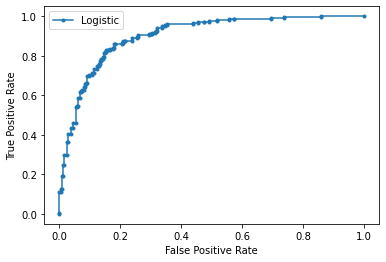

In [ ]:
# plot the roc curve for the model
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

implement roc_auc_score and roc_curve functions on your own

In [ ]:
def roc_curve(testy, lrprobs):
    return fpr, tpr

def roc_auc_score(testy, lr_probs):
    return auc